# Adversarial Attack on a Network Intrusion Detection Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install adversarial-robustness-toolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 16.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

# Loading the data

In [ ]:
# Data directory for NSL-KDD dataset
data_path = "drive/MyDrive/AML_Course/Spring_2025/Other_Codes/Intrusion_Detection/"

In [ ]:
# Load the data into pandas dataframes
train_df = pd.read_csv(data_path + "KDDTrain+.csv")
test_df = pd.read_csv(data_path + "KDDTest+.csv")

# Print the first 5 rows of the train data
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,attack score,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0


In [ ]:
print("Shape of the training data", train_df.shape)
print("Number of data points", train_df.shape[0])
print("Number of features",train_df.shape[1])

Shape of the training data (125973, 44)
Number of data points 125973
Number of features 44


In [ ]:
print("Shape of the testing data", test_df.shape)
print("Number of data points", test_df.shape[0])
print("Number of features",test_df.shape[1])

Shape of the testing data (22544, 44)
Number of data points 22544
Number of features 44


# Data exploration

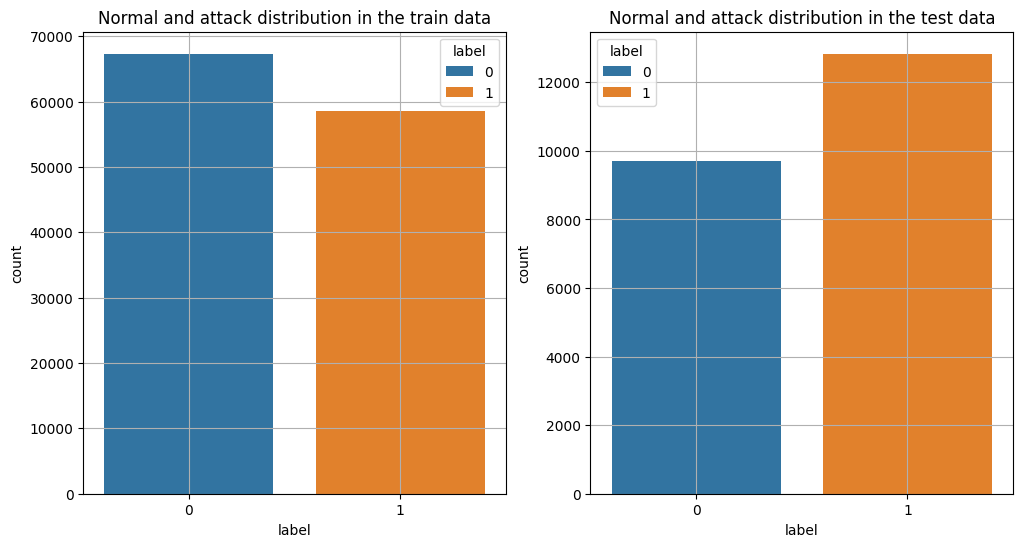

In [ ]:
# Plot the distributions of normal class 0 and attack class 1
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.countplot(x ='label' , data =train_df, hue='label')
plt.title("Normal and attack distribution in the train data")
plt.grid()
plt.subplot(1,2,2)
sns.countplot(x ='label' , data=test_df, hue ='label')
plt.title("Normal and attack distribution in the test data")
plt.grid()
plt.show()

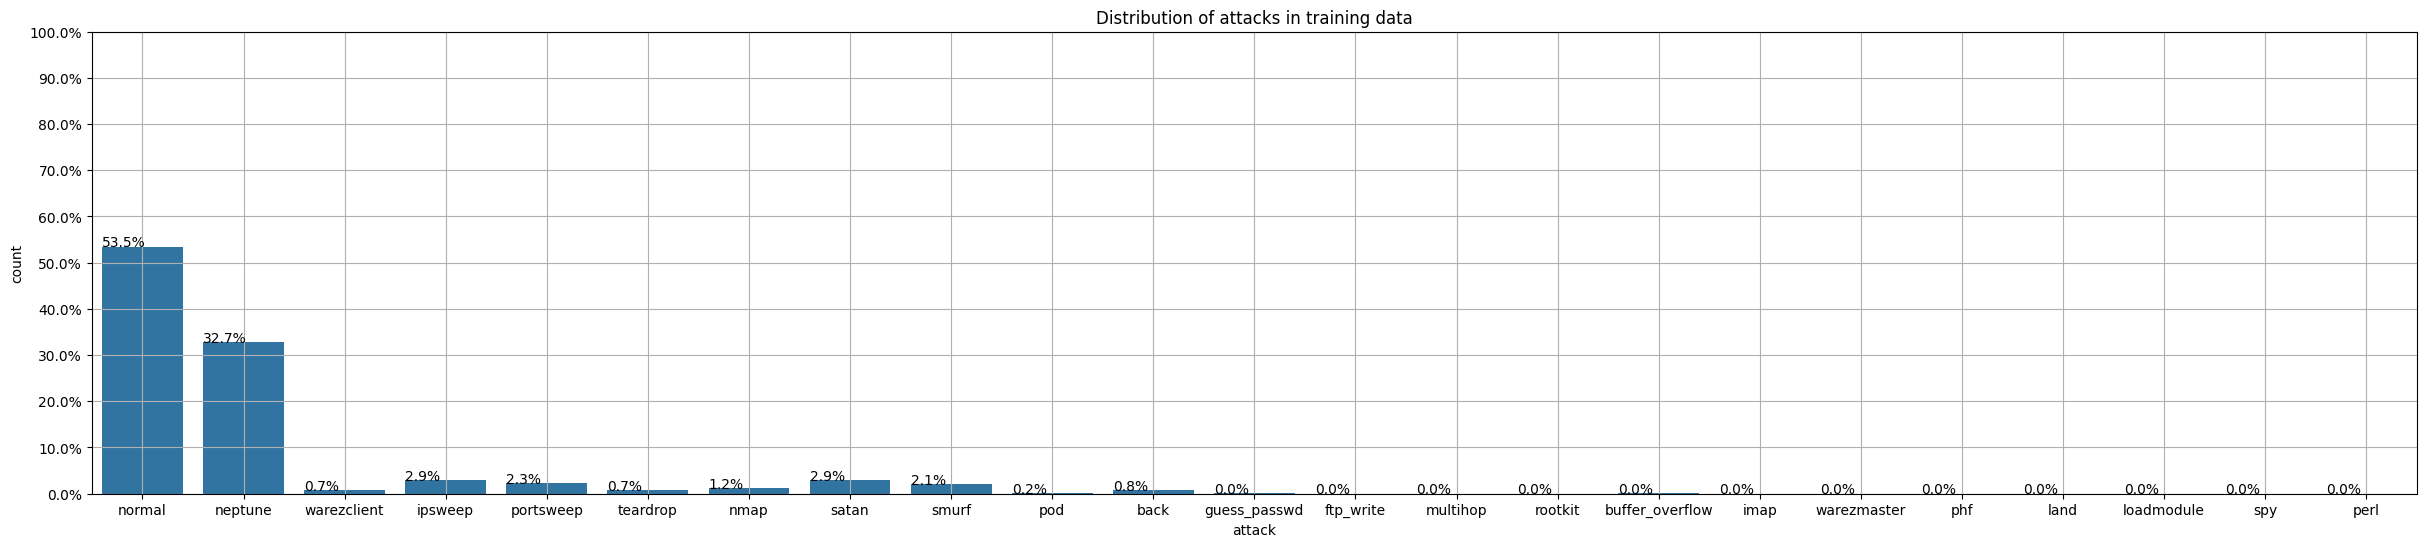

In [ ]:
# Plot the distribution of all attacks in the train data
f, ax = plt.subplots(figsize=(30,6))
# Plot the data counts per attack (there are 23 attack classes)
ax = sns.countplot(x="attack", data=train_df)
# The total number of rows
total = len(train_df) * 1
# Plot bars for each attack
for p in ax.patches:
   ax.annotate('{:.1f}%'.format(100*p.get_height()/total), (p.get_x(), p.get_height()))
# Set axis ticks and thicklabels
ax.yaxis.set_ticks(np.linspace(0, total, 11))
ax.set_yticklabels(map('{:.1f}%'.format, 100*ax.yaxis.get_majorticklocs()/total))

plt.title("Distribution of attacks in training data")
plt.grid()
plt.show()

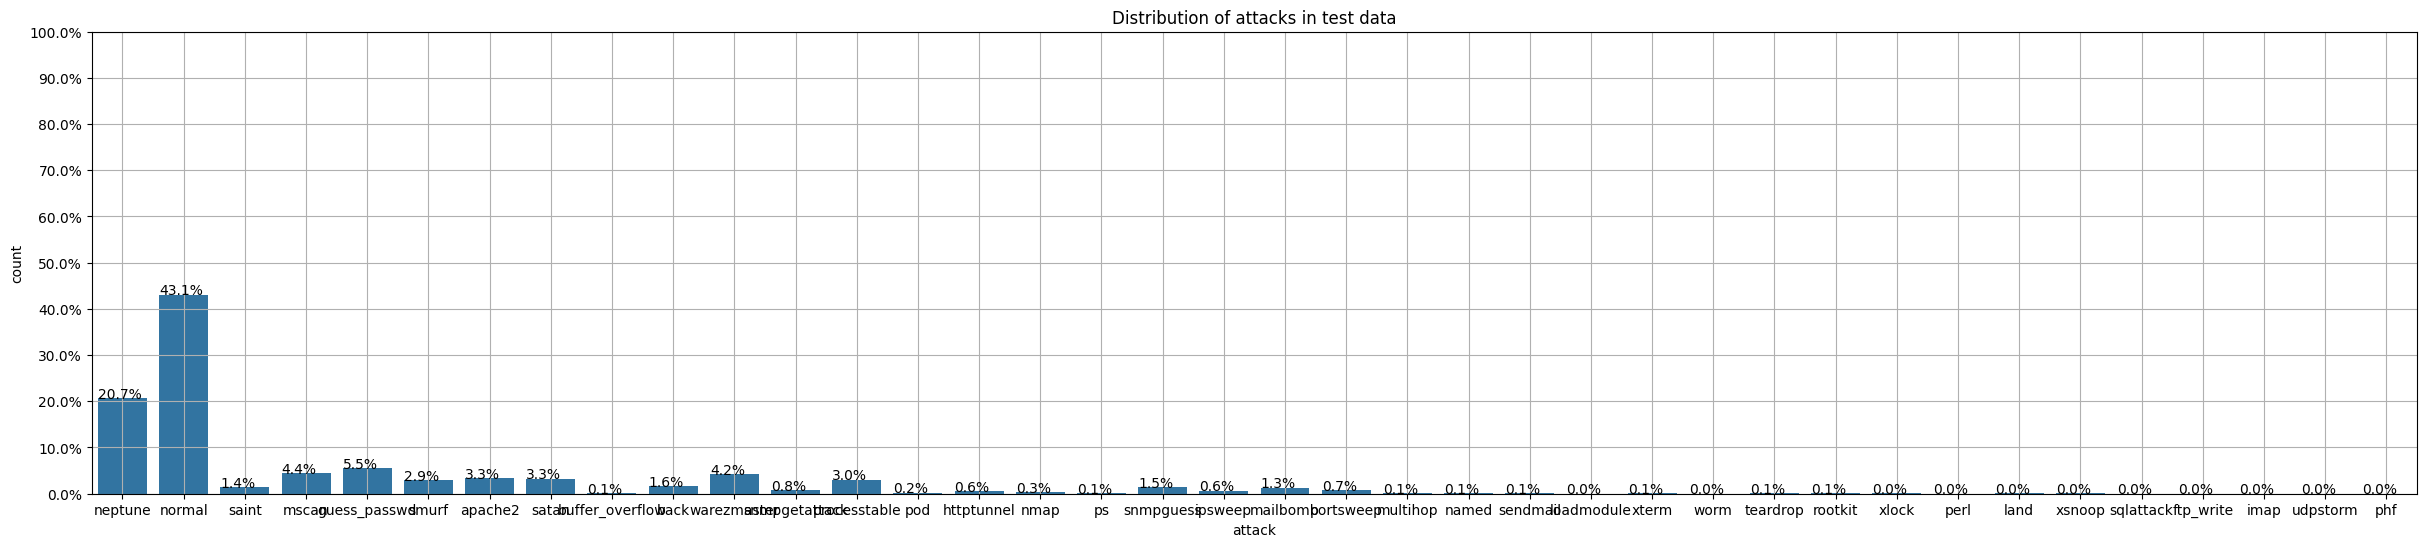

In [ ]:
# And plot the distribution of all attacks in the test data
f, ax = plt.subplots(figsize=(30,6))
# Plot the data counts per attack (there are 23 attack classes)
ax = sns.countplot(x="attack", data=test_df)
# The total number of rows
total = len(test_df) * 1
# Plot bars for each attack
for p in ax.patches:
   ax.annotate('{:.1f}%'.format(100*p.get_height()/total), (p.get_x(), p.get_height()))
# Set axis ticks and thicklabels
ax.yaxis.set_ticks(np.linspace(0, total, 11))
ax.set_yticklabels(map('{:.1f}%'.format, 100*ax.yaxis.get_majorticklocs()/total))

plt.title("Distribution of attacks in test data")
plt.grid()
plt.show()

In [ ]:
# Print the sorted number of datapoints belonging to each attack class
train_class_distribution = train_df['attack'].value_counts()

# Sorting them in decreasing order (by number of datapoints)
sorted_yi = np.argsort(-train_class_distribution.values)
# Printing the number of datapoints and the percetange
for i in sorted_yi:
    print('Number of data points in class', i+1, ':',train_class_distribution.values[i], '(', np.round((train_class_distribution.values[i]/len(train_df)*100), 3), '%)')

Number of data points in class 1 : 67343 ( 53.458 %)
Number of data points in class 2 : 41214 ( 32.717 %)
Number of data points in class 3 : 3633 ( 2.884 %)
Number of data points in class 4 : 3599 ( 2.857 %)
Number of data points in class 5 : 2931 ( 2.327 %)
Number of data points in class 6 : 2646 ( 2.1 %)
Number of data points in class 7 : 1493 ( 1.185 %)
Number of data points in class 8 : 956 ( 0.759 %)
Number of data points in class 9 : 892 ( 0.708 %)
Number of data points in class 10 : 890 ( 0.707 %)
Number of data points in class 11 : 201 ( 0.16 %)
Number of data points in class 12 : 53 ( 0.042 %)
Number of data points in class 13 : 30 ( 0.024 %)
Number of data points in class 14 : 20 ( 0.016 %)
Number of data points in class 15 : 18 ( 0.014 %)
Number of data points in class 16 : 11 ( 0.009 %)
Number of data points in class 17 : 10 ( 0.008 %)
Number of data points in class 18 : 9 ( 0.007 %)
Number of data points in class 19 : 8 ( 0.006 %)
Number of data points in class 20 : 7 ( 0.

In [ ]:
# Repeat the same for the test data
test_class_distribution = test_df['attack'].value_counts()

# Sorting them in decreasing order (by number of datapoints)
sorted_yi = np.argsort(-test_class_distribution.values)
# Printing the number of datapoints and the percetange
for i in sorted_yi:
    print('Number of data points in class', i+1, ':',test_class_distribution.values[i], '(', np.round((test_class_distribution.values[i]/len(test_df)*100), 3), '%)')

Number of data points in class 1 : 9711 ( 43.076 %)
Number of data points in class 2 : 4657 ( 20.657 %)
Number of data points in class 3 : 1231 ( 5.46 %)
Number of data points in class 4 : 996 ( 4.418 %)
Number of data points in class 5 : 944 ( 4.187 %)
Number of data points in class 6 : 737 ( 3.269 %)
Number of data points in class 7 : 735 ( 3.26 %)
Number of data points in class 8 : 685 ( 3.039 %)
Number of data points in class 9 : 665 ( 2.95 %)
Number of data points in class 10 : 359 ( 1.592 %)
Number of data points in class 11 : 331 ( 1.468 %)
Number of data points in class 12 : 319 ( 1.415 %)
Number of data points in class 13 : 293 ( 1.3 %)
Number of data points in class 14 : 178 ( 0.79 %)
Number of data points in class 15 : 157 ( 0.696 %)
Number of data points in class 16 : 141 ( 0.625 %)
Number of data points in class 17 : 133 ( 0.59 %)
Number of data points in class 18 : 73 ( 0.324 %)
Number of data points in class 19 : 41 ( 0.182 %)
Number of data points in class 20 : 20 ( 0.0

In [ ]:
# The dataset have attacks that are present in the test set and not in the train set
# Print those attacks

trn = set(train_df['attack'].unique())
tst = set(test_df['attack'].unique())

extra = tst - trn

print(extra)
print("*"*100)
print("Number of extra attacks that are present only in the test set:", len(extra))

{'udpstorm', 'httptunnel', 'worm', 'ps', 'xterm', 'xsnoop', 'mscan', 'snmpguess', 'apache2', 'xlock', 'sendmail', 'snmpgetattack', 'sqlattack', 'processtable', 'mailbomb', 'named', 'saint'}
****************************************************************************************************
Number of extra attacks that are present only in the test set: 17


# Convert categorical columns into numerical values

In [ ]:
# Display the columns and the datatype for each column
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [ ]:
# Convert the columns with categorical values into numerical values
from sklearn.preprocessing import OrdinalEncoder

categs_feats = train_df[['protocol_type', 'service', 'flag', 'attack']]
encoder = OrdinalEncoder()
categs_encoded = encoder.fit_transform(categs_feats)

In [ ]:
train_df[['protocol_type', 'service', 'flag', 'attack']] = pd.DataFrame(categs_encoded, columns=categs_feats.columns, index=categs_feats.index)
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,attack score,label
0,0,1.0,20.0,9.0,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,11.0,20,0
1,0,2.0,44.0,9.0,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,11.0,15,0
2,0,1.0,49.0,5.0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,9.0,19,1
3,0,1.0,24.0,9.0,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,11.0,21,0
4,0,1.0,24.0,9.0,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,11.0,21,0


In [ ]:
# Create a training dataset
X_train = train_df.drop(['attack', 'attack score', 'label'], axis=1)
y_train = train_df['label']

In [ ]:
# Repeat the same for the test dataset
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  int64  
 1   protocol_type                22544 non-null  object 
 2   service                      22544 non-null  object 
 3   flag                         22544 non-null  object 
 4   src_bytes                    22544 non-null  int64  
 5   dst_bytes                    22544 non-null  int64  
 6   land                         22544 non-null  int64  
 7   wrong_fragment               22544 non-null  int64  
 8   urgent                       22544 non-null  int64  
 9   hot                          22544 non-null  int64  
 10  num_failed_logins            22544 non-null  int64  
 11  logged_in                    22544 non-null  int64  
 12  num_compromised              22544 non-null  int64  
 13  root_shell      

In [ ]:
categs_feats = test_df[['protocol_type', 'service', 'flag', 'attack']]
encoder = OrdinalEncoder()
categs_encoded = encoder.fit_transform(categs_feats)

In [ ]:
test_df[['protocol_type', 'service', 'flag', 'attack']] = pd.DataFrame(categs_encoded, columns=categs_feats.columns, index=categs_feats.index)
test_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,attack score,label
0,0,1.0,45.0,1.0,0,0,0,0,0,0,...,0.06,0.00,0.00,0.0,0.0,1.00,1.00,14.0,21,1
1,0,1.0,45.0,1.0,0,0,0,0,0,0,...,0.06,0.00,0.00,0.0,0.0,1.00,1.00,14.0,21,1
2,2,1.0,19.0,9.0,12983,0,0,0,0,0,...,0.04,0.61,0.02,0.0,0.0,0.00,0.00,16.0,21,0
3,0,0.0,13.0,9.0,20,0,0,0,0,0,...,0.00,1.00,0.28,0.0,0.0,0.00,0.00,24.0,15,1
4,1,1.0,55.0,2.0,0,15,0,0,0,0,...,0.17,0.03,0.02,0.0,0.0,0.83,0.71,11.0,11,1


In [ ]:
# Create a test dataset
X_test = test_df.drop(['attack', 'attack score', 'label'], axis=1)
y_test = test_df['label']

# Normalize the data values in each column to the range [0,1]

In [ ]:
# Standardize features by scaling each feature to range [0, 1]
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Note: the variables are now numpy arrays, and not pandas dataframes
print('Data type:', type(X_train))

# Display the shapes of train and test datasets
print('\nTrain shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

# Display the range to make sure they are in the [0, 1] range
print('\nMax value', np.max(X_train))
print('Min value', np.min(X_train))
print('Average value', np.mean(X_train))

Data type: <class 'numpy.ndarray'>

Train shape: (125973, 41)
Test shape: (22544, 41)

Max value 1.0
Min value 0.0
Average value 0.16355979490070746


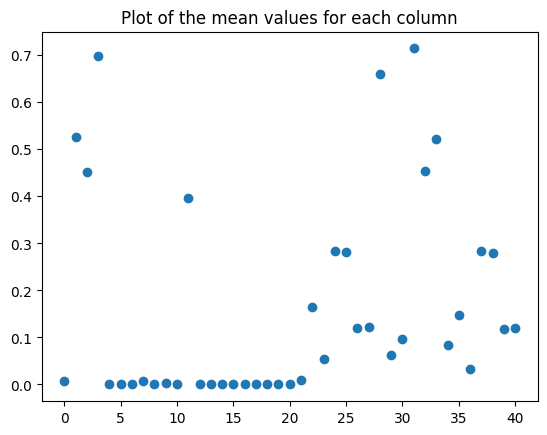

In [ ]:
# Let's examine the mean values for each of the columns
plt.plot(np.mean(X_train, axis=0), 'o')
plt.title("Plot of the mean values for each column")
plt.show()

# Train Conventional ML Classifiers

In [ ]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import neighbors
from sklearn.naive_bayes import GaussianNB

In [ ]:
print('LOGISTIC REGRESSION')
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

print('Accuracy:', model_lr.score(X_test, y_test))

LOGISTIC REGRESSION
Accuracy: 0.7538591199432222


In [ ]:
print('*** RANDOM FOREST ***')
model_rf = RandomForestClassifier(verbose=0, warm_start=True)
model_rf.fit(X_train, y_train)

print('Accuracy:', model_rf.score(X_test, y_test))

*** RANDOM FOREST ***
Accuracy: 0.7644606103619588


In [ ]:
print('*** DECISION TREE ***')
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train, y_train)

print('Accuracy:', model_dt.score(X_test, y_test))

*** DECISION TREE ***
Accuracy: 0.7943133427963094


# Deep NN

In [ ]:
import tensorflow
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import datetime
now = datetime.datetime.now

In [ ]:
# Define the layers for the network
input_seq = Input(shape=(41,))

hidden = Dense(1024, activation='relu')(input_seq)
hidden = Dropout(0.25)(hidden)
hidden = Dense(512, activation='relu')(hidden)
hidden = Dropout(0.25)(hidden)
hidden = Dense(256, activation='relu')(hidden)
hidden = Dropout(0.25)(hidden)
predictions = Dense(2, activation='softmax')(hidden)

# The model
model = Model(inputs=input_seq, outputs=predictions)

In [ ]:
model.compile(optimizer=Adam(learning_rate = 1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

Training time: 0:02:42.719525


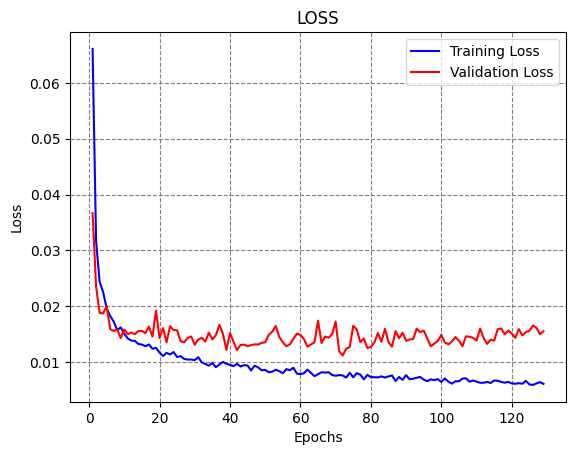

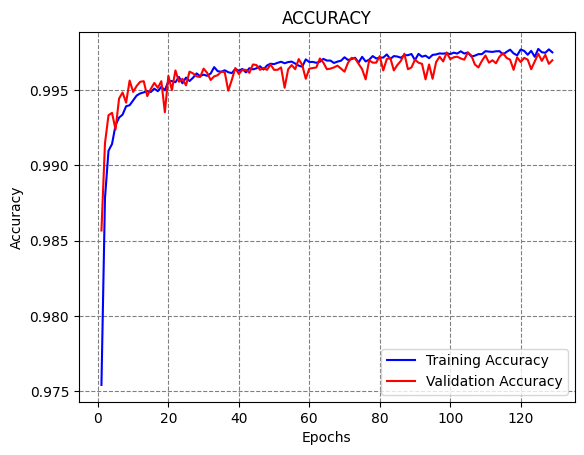

In [ ]:
# Fit model
t = now()
callbacks = [EarlyStopping(monitor='val_accuracy', patience=30)]
history = model.fit(X_train, y_train, batch_size=256, epochs=300,
                     validation_split=0.2, verbose=0, callbacks=callbacks)

print('Training time: %s' % (now() - t))

# Plot the loss and accuracy
train_loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochsn = np.arange(1, len(train_loss)+1,1)
plt.plot(epochsn,train_loss, 'b', label='Training Loss')
plt.plot(epochsn,val_loss, 'r', label='Validation Loss')
plt.grid(color='gray', linestyle='--')
plt.legend()
plt.title('LOSS')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.figure()
plt.plot(epochsn, acc, 'b', label='Training Accuracy')
plt.plot(epochsn, val_acc, 'r', label='Validation Accuracy')
plt.grid(color='gray', linestyle='--')
plt.legend()
plt.title('ACCURACY')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
# Evaluate on test data
evals_test = model.evaluate(X_test, y_test)
print("Classification Accuracy: ", evals_test[1])

705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7978 - loss: 3.5358
Classification Accuracy:  0.7928051948547363


# Attacks

In [ ]:
# Creating adversarial test sets of 1000 samples

# Define a random seed (to draw the same smamples)
np.random.seed(2)

ind = np.random.randint(1, 20000, 1000)

# Set of image for testing the attacks
adv_test_data = X_test[ind]
adv_test_labels = y_test[ind]

In [ ]:
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import FastGradientMethod

In [ ]:
classifier = TensorFlowV2Classifier(model=model, nb_classes=2,
                                    clip_values=(0, 1), input_shape=(41,), loss_object=tensorflow.keras.losses.SparseCategoricalCrossentropy())

In [ ]:
# FGSM attack
epsilon = [0.01, 0.025, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8]

fgsm_attack_acc = []
for eps in epsilon:
    attack_fgsm = FastGradientMethod(estimator=classifier, eps=eps)
    fgsm_attack_adv_data = attack_fgsm.generate(adv_test_data)
    loss_test, accuracy_test = model.evaluate(fgsm_attack_adv_data, adv_test_labels)
    fgsm_attack_acc.append(accuracy_test)
    perturbation = np.mean(np.abs((fgsm_attack_adv_data - adv_test_data)))
    print('Accuracy on adversarial test data: {:4.2f}%'.format(accuracy_test * 100))
    print('Average perturbation: {:4.2f}'.format(perturbation))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7793 - loss: 1.7254
Accuracy on adversarial test data: 78.00%
Average perturbation: 0.00
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6847 - loss: 3.1261 
Accuracy on adversarial test data: 70.10%
Average perturbation: 0.01
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6252 - loss: 5.0684
Accuracy on adversarial test data: 63.80%
Average perturbation: 0.02
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5230 - loss: 9.5296 
Accuracy on adversarial test data: 54.30%
Average perturbation: 0.05
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4653 - loss: 18.8675
Accuracy on adversarial test data: 48.00%
Average perturbation: 0.09
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4701 - loss: 30.8071
Accuracy on adversarial test data: 48.70%
Average perturbation: 0.14
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4781 - loss: 65.6533
Accuracy on adversarial test data: 49.50%
Average perturbation: 0.22


In [ ]:
# Create adversarail samples and display them
attack_fgsm = FastGradientMethod(estimator=classifier, eps=0.1)
fgsm_attack_adv_data = attack_fgsm.generate(adv_test_data)

np.set_printoptions(precision=2, suppress=True)
print("First test example:", adv_test_data[0])
print("\nFirst advesarial example:", fgsm_attack_adv_data[0])

First test example: [0.   1.   0.16 0.9  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 1.   0.   0.   0.11 0.83 0.79 0.07 0.79 0.01 0.   0.   0.21 0.  ]

First advesarial example: [0.   0.9  0.26 0.8  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.
 0.   0.   0.1  0.   0.1  0.1  0.1  0.1  0.1  0.1  0.   0.1  0.1  0.1
 0.9  0.1  0.1  0.21 0.73 0.69 0.17 0.89 0.11 0.1  0.1  0.11 0.  ]


In [ ]:
# Second adversarial sample
np.set_printoptions(precision=2, suppress=True)
print("Second test example:", adv_test_data[1])
print("\nSecond advesarial example:", fgsm_attack_adv_data[1])

Second test example: [0.   1.   0.16 0.9  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.01 0.01 0.   0.   0.   0.
 1.   0.   0.43 1.   0.99 0.99 0.01 0.   0.   0.   0.   0.   0.  ]

Second advesarial example: [0.   0.9  0.26 0.8  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.
 0.   0.   0.1  0.   0.1  0.1  0.   0.1  0.11 0.   0.   0.   0.1  0.1
 0.9  0.1  0.33 1.   0.89 1.   0.11 0.1  0.1  0.1  0.1  0.1  0.1 ]
